In [3]:
pip install medmnist -q


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [1]:
from medmnist import ChestMNIST
import torch
from torch.utils.data import Dataset
from torchvision.transforms import v2
import sys

sys.path.append("..")
from data import draw_circle, draw_star, draw_wave

In [2]:
from shared import BinaryChestMNIST

ds_common = dict(
        shape="star", star_size=20, blend_range=(0.6,0.8), color=255,
        randomize_star_pos=True, download=True, size=224,
    )

eval_tf = v2.Compose([
        v2.ToImage(),
        v2.ToDtype(torch.float32, scale=True),
    ])

In [3]:
test_ds = BinaryChestMNIST("test",
        spurious_prob_pos=0.0, spurious_prob_neg=0.0,
        transform=eval_tf, **ds_common)

train_ds = BinaryChestMNIST("train",
        spurious_prob_pos=0.0, spurious_prob_neg=0.0,
        transform=eval_tf, **ds_common)

In [9]:
from collections import Counter

def print_split_distribution(dataset, split_name):
    labels = [dataset[i][1].item() for i in range(len(dataset))]
    counts = Counter(labels)
    total = len(labels)
    print(f"\n{split_name}")
    print(f"  Normal   (0): {counts[0]:>6}  ({100*counts[0]/total:.1f}%)")
    print(f"  Abnormal (1): {counts[1]:>6}  ({100*counts[1]/total:.1f}%)")
    print(f"  Total       : {total:>6}")

print_split_distribution(train_ds, "Train")
# print_split_distribution(val_dataset,   "Val")
# print_split_distribution(test_ds,  "Test")


Train
  Normal   (0):  42405  (54.0%)
  Abnormal (1):  36063  (46.0%)
  Total       :  78468


-----

In [4]:
import itertools
import numpy as np
from PIL import Image, ImageDraw, ImageFont
from medmnist import ChestMNIST


def _local_color(img, cx, cy, size):
    arr = np.array(img)
    x0, y0 = max(cx - size, 0), max(cy - size, 0)
    x1, y1 = min(cx + size, arr.shape[1]), min(cy + size, arr.shape[0])
    local_mean = arr[y0:y1, x0:x1].mean()
    return int(min(local_mean + 30, 255))


def draw_star(img, size=20, pos=(10, 10), color=None, blend_alpha=0.5):
    img = img.copy()
    cx, cy = pos
    if color is None:
        color = _local_color(img, cx, cy, size)
    overlay = img.copy()
    draw = ImageDraw.Draw(overlay)
    outer, inner = size, size / 2.5
    points = []
    for i in range(10):
        angle = i * 36 - 90
        r = outer if i % 2 == 0 else inner
        rad = np.radians(angle)
        points.append((cx + r * np.cos(rad), cy + r * np.sin(rad)))
    draw.polygon(points, fill=color)
    return Image.blend(img, overlay, alpha=blend_alpha)


def draw_circle(img, size=20, pos=(10, 10), color=None, blend_alpha=0.5):
    img = img.copy()
    cx, cy = pos
    if color is None:
        color = _local_color(img, cx, cy, size)
    overlay = img.copy()
    draw = ImageDraw.Draw(overlay)
    r = size
    draw.ellipse([cx - r, cy - r, cx + r, cy + r], fill=color)
    return Image.blend(img, overlay, alpha=blend_alpha)


def draw_wave(img, size=20, pos=(10, 10), color=None, blend_alpha=0.5):
    img = img.copy()
    cx, cy = pos
    if color is None:
        color = _local_color(img, cx, cy, size)
    overlay = img.copy()
    draw = ImageDraw.Draw(overlay)
    w, h = img.size
    amplitude = size * 0.4
    thickness = max(size // 4, 2)
    x_start = max(cx - size, 0)
    x_end = min(cx + size, w)
    freq = 2 * np.pi / size  # one full cycle across `size` pixels
    for x in range(x_start, x_end):
        y_centre = int(cy + amplitude * np.sin(freq * (x - cx)))
        y0 = max(y_centre - thickness // 2, 0)
        y1 = min(y_centre + thickness // 2, h - 1)
        for y in range(y0, y1 + 1):
            draw.point((x, y), fill=color)
    return Image.blend(img, overlay, alpha=blend_alpha)


SHAPE_FNS = {
    "star":   draw_star,
    "circle": draw_circle,
    "wave":   draw_wave,
}

# ── match your sweep axes (edit these if you change them) ────
shapes       = ["star", "circle", "wave"]
sizes        = {"small": 10, "medium": 15, "large": 20, "xl": 25}
blend_ranges = {"subtle": (0.4, 0.6), "moderate": (0.6, 0.8)}

IMG_SIZE = 224

ds = ChestMNIST(split="test", download=True, size=IMG_SIZE)
base_img = None
for img, label in ds:
    if label.any():          # pick a positive (has pathology)
        base_img = img
        break

cols_per_blend = list(sizes.keys())
blend_labels   = list(blend_ranges.keys())
n_col_groups   = len(blend_labels)
n_cols         = 1 + len(cols_per_blend) * n_col_groups   # 1 for original
n_rows         = len(shapes)

cell_size  = IMG_SIZE
pad        = 4
header_h   = 50       # space for column labels
row_label_w = 70      # space for row labels

grid_w = row_label_w + n_cols * (cell_size + pad) + pad
grid_h = header_h + n_rows * (cell_size + pad) + pad

grid = Image.new("RGB", (grid_w, grid_h), color=(255, 255, 255))
draw = ImageDraw.Draw(grid)

try:
    font = ImageFont.truetype("arial.ttf", 14)
    font_small = ImageFont.truetype("arial.ttf", 11)
except OSError:
    font = ImageFont.load_default()
    font_small = font

col = 0
# "Original" header
x = row_label_w + pad + col * (cell_size + pad) + cell_size // 2
draw.text((x, 5), "original", fill=(0, 0, 0), font=font, anchor="mt")
col += 1

for blend_label in blend_labels:
    group_start_x = row_label_w + pad + col * (cell_size + pad)
    group_end_x   = row_label_w + pad + (col + len(cols_per_blend)) * (cell_size + pad) - pad
    mid_x = (group_start_x + group_end_x) // 2
    lo, hi = blend_ranges[blend_label]
    draw.text((mid_x, 3), f"{blend_label} (alpha {lo}-{hi})",
              fill=(0, 0, 0), font=font, anchor="mt")

    for size_label in cols_per_blend:
        x = row_label_w + pad + col * (cell_size + pad) + cell_size // 2
        px = sizes[size_label]
        draw.text((x, 22), f"{size_label} ({px}px)",
                  fill=(100, 100, 100), font=font_small, anchor="mt")
        col += 1

for row_i, shape in enumerate(shapes):
    y = header_h + pad + row_i * (cell_size + pad)

    # row label
    draw.text((5, y + cell_size // 2), shape,
              fill=(0, 0, 0), font=font, anchor="lm")

    col = 0
    # original (no spurious feature)
    x = row_label_w + pad + col * (cell_size + pad)
    orig_rgb = base_img.convert("RGB")
    grid.paste(orig_rgb, (x, y))
    col += 1

    draw_fn = SHAPE_FNS[shape]
    for blend_label in blend_labels:
        lo, hi = blend_ranges[blend_label]
        mid_alpha = (lo + hi) / 2          # use midpoint for the preview
        for size_label in cols_per_blend:
            px = sizes[size_label]
            x = row_label_w + pad + col * (cell_size + pad)

            # draw the feature at a fixed central-ish position
            margin = px + 4
            pos = (IMG_SIZE // 4 + margin, IMG_SIZE // 4 + margin)

            modified = draw_fn(base_img, size=px, pos=pos, blend_alpha=mid_alpha)
            grid.paste(modified.convert("RGB"), (x, y))
            col += 1

out_path = "spurious_feature_grid.png"
grid.save(out_path, dpi=(150, 150))
print(f"Saved to {out_path}  ({grid_w}x{grid_h} px)")

Saved to spurious_feature_grid.png  (2126x738 px)


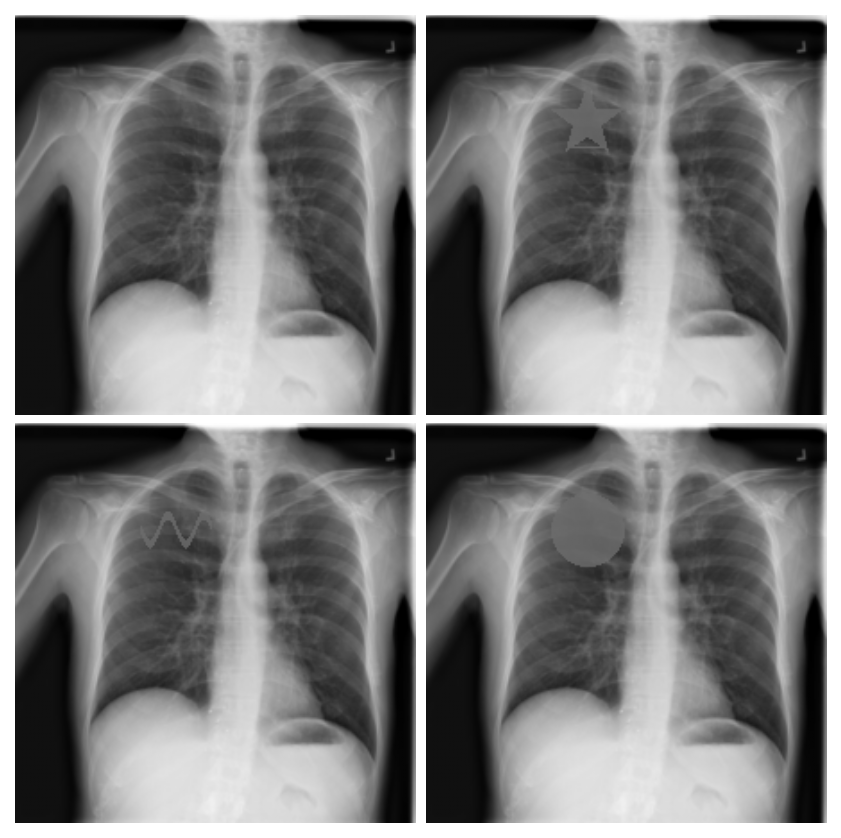

In [5]:
import matplotlib.pyplot as plt
from medmnist import ChestMNIST

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "text.color":       "black",
    "font.family":      "monospace",
})

IMG_SIZE = 224
_ds  = ChestMNIST(split="test", download=True, size=IMG_SIZE)
base, _ = _ds[3]

PATTERNS = {
    "Normal": None,
    "Star":   draw_star,
    "Wave":   draw_wave,
    "Circle": draw_circle,
}
POS   = (IMG_SIZE // 4, IMG_SIZE // 4)
ALPHA = 0.8

fig, axes = plt.subplots(2, 2, figsize=(7, 7), dpi=150,
                         facecolor="white",
                         gridspec_kw=dict(hspace=0.02, wspace=0.02))

for ax, (name, fn) in zip(axes.flat, PATTERNS.items()):
    img_show = base if fn is None else fn(base, size=20, pos=(90,60), blend_alpha=ALPHA)
    ax.imshow(img_show, cmap="gray", interpolation="bilinear")
    # ax.set_title(name, color="black", fontsize=12, fontweight="bold", pad=6)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

# fig.suptitle("Spurious Feature Variants", fontsize=13, fontweight="bold",
#              color="black", y=1.0)

plt.savefig("spurious_2x2.png", dpi=3000, bbox_inches="tight",
            facecolor="white", edgecolor="none")
plt.show()


In [7]:
_ds[3]

(<PIL.Image.Image image mode=L size=224x224>,
 array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]))